# Distillation Teacher Sweep — Results

Fetches per-teacher F1 scores from the `distillation-teacher-sweep` WandB project and
visualises performance on each benchmark.

Each teacher model was distilled into Llama-3.1-8B under two conditions:
- **Distilled Reasoning** — student outputs reasoning + prompt harm prediction
- **Distilled Reasoning + Intent** — student outputs reasoning + intent + prompt harm prediction

The Wildguard paper's reported scores are shown as a reference baseline.

In [1]:
import json
import os
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import wandb
from dotenv import load_dotenv

load_dotenv()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

/scratch/s4626451/projects/intention-jailbreak/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/scratch/s4626451/projects/intention-jailbreak/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by as

In [2]:
# ── WandB projects ────────────────────────────────────────────────────────────
ENTITY      = os.getenv("WANDB_ENTITY", "intention-analysis")
PROJECT_V2  = "distillation-teacher-sweep-v2"   # retrained with correct trace format
PROJECT_V1  = "distillation-teacher-sweep"       # GPT-OSS-120B only (already correct format)

# Teachers whose v1 results are still valid (not re-run in v2)
V1_ONLY_TEACHERS = {"openai-gpt-oss-120b"}

# ── Output ────────────────────────────────────────────────────────────────────
FIGS_DIR = Path("../data/imgs")
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset display names (wandb key prefix → human label) ────────────────────
DATASET_NAMES = {
    "annotated-intents": "Annotated Intents",
    "wildguardmix":      "WildguardTest",
    "xstest":            "XSTest",
}

# ── Condition normalization ────────────────────────────────────────────────────
# Older runs store keys without 'finetuned_' prefix; newer runs include it.
CONDITION_DISPLAY = {
    "reasoning_classification":           "Distilled Reasoning",
    "finetuned_reasoning_classification": "Distilled Reasoning",
    "reasoning_generation":               "Distilled Reasoning + Intent",
    "finetuned_reasoning_generation":     "Distilled Reasoning + Intent",
}

# ── Teacher display names ─────────────────────────────────────────────────────
# Keys are teacher slugs WITHOUT any run suffix (e.g. "-v2").
TEACHER_DISPLAY = {
    "RedHatAI-gemma-3-27b-it-quantized.w4a16":             "Gemma-3-27B",
    "hugging-quants-Meta-Llama-3.1-70B-Instruct-AWQ-INT4": "Llama-3.1-70B",
    "openai-gpt-oss-120b":                                  "GPT-OSS-120B",
    "RedHatAI-Qwen3-32B-quantized.w4a16":                   "Qwen3-32B",
    "cyankiwi-Qwen3.5-27B-AWQ-4bit":                        "Qwen3.5-27B",
}

# ── Wildguard paper baselines (F1) ────────────────────────────────────────────
PAPER_BASELINES = {
    "WildguardTest": 0.890,
    "XSTest":        0.945,
}

# ── Color palette (matches safety_experiment_results.ipynb) ──────────────────
CONDITION_COLORS = {
    "Distilled Reasoning":          "#4393c3",  # steel blue
    "Distilled Reasoning + Intent": "#d6604d",  # orange-red — clearly distinct
    "Wildguard (reported)":         "#b3b3b3",  # grey
}

## Fetch runs from WandB

In [3]:
def _parse_runs(runs, run_suffix=None):
    """Extract records from a list of wandb runs, stripping an optional suffix from run names."""
    records = []
    for run in runs:
        # Strip version suffix from run name to get the canonical teacher slug
        slug = run.name
        if run_suffix and slug.endswith(f"-{run_suffix}"):
            slug = slug[: -len(f"-{run_suffix}")]

        teacher = TEACHER_DISPLAY.get(slug, slug)

        raw     = run.summary._json_dict
        summary = json.loads(raw) if isinstance(raw, str) else raw

        for key in summary:
            if not key.endswith("/f1"):
                continue
            parts = key.split("/")
            if len(parts) != 3:
                continue
            dataset_key, cond_key, _ = parts

            dataset   = DATASET_NAMES.get(dataset_key, dataset_key)
            condition = CONDITION_DISPLAY.get(cond_key)
            if condition is None:
                continue

            prefix = f"{dataset_key}/{cond_key}/"
            records.append({
                "teacher":   teacher,
                "dataset":   dataset,
                "condition": condition,
                "f1":        summary.get(prefix + "f1",        None),
                "precision": summary.get(prefix + "precision", None),
                "recall":    summary.get(prefix + "recall",    None),
                "accuracy":  summary.get(prefix + "accuracy",  None),
                "run_id":    run.id,
                "project":   run.project,
            })
    return records


api = wandb.Api()

# v2: Gemma, Qwen3, Llama-70B — retrained on correctly-ordered traces
runs_v2 = api.runs(f"{ENTITY}/{PROJECT_V2}")
print(f"Found {len(runs_v2)} runs in {PROJECT_V2}")
records = _parse_runs(runs_v2, run_suffix="v2")

# v1: GPT-OSS-120B only — traces were already in the correct format
runs_v1 = api.runs(f"{ENTITY}/{PROJECT_V1}")
print(f"Found {len(runs_v1)} runs in {PROJECT_V1}")
for run in runs_v1:
    if run.name in V1_ONLY_TEACHERS:
        records += _parse_runs([run], run_suffix=None)

df = pd.DataFrame(records)
print(f"\nParsed {len(df)} rows across {df['teacher'].nunique()} teachers")
df

Found 2 runs in distillation-teacher-sweep-v2
Found 4 runs in distillation-teacher-sweep

Parsed 18 rows across 3 teachers


,teacher,dataset,condition,f1,precision,recall,accuracy,run_id,project
0,Gemma-3-27B,Annotated Intents,Distilled Reasoning,0.728477,0.785714,0.679012,0.757396,gumg0mqm,distillation-teacher-sweep-v2
1,Gemma-3-27B,Annotated Intents,Distilled Reasoning + Intent,0.666667,0.728571,0.614458,0.698225,gumg0mqm,distillation-teacher-sweep-v2
2,Gemma-3-27B,WildguardTest,Distilled Reasoning,0.832168,0.877581,0.791223,0.858323,gumg0mqm,distillation-teacher-sweep-v2
3,Gemma-3-27B,WildguardTest,Distilled Reasoning + Intent,0.842105,0.877345,0.809587,0.865407,gumg0mqm,distillation-teacher-sweep-v2
4,Gemma-3-27B,XSTest,Distilled Reasoning,0.903073,0.856502,0.955000,0.908686,gumg0mqm,distillation-teacher-sweep-v2
5,Gemma-3-27B,XSTest,Distilled Reasoning + Intent,0.885714,0.845455,0.930000,0.893096,gumg0mqm,distillation-teacher-sweep-v2
6,Qwen3-32B,Annotated Intents,Distilled Reasoning,0.719512,0.737500,0.702381,0.732558,nsl12ra8,distillation-teacher-sweep-v2
7,Qwen3-32B,Annotated Intents,Distilled Reasoning + Intent,0.702703,0.800000,0.626506,0.742690,nsl12ra8,distillation-teacher-sweep-v2
8,Qwen3-32B,WildguardTest,Distilled Reasoning,0.847502,0.828680,0.867198,0.861602,nsl12ra8,distillation-teacher-sweep-v2
9,Qwen3-32B,WildguardTest,Distilled Reasoning + Intent,0.837500,0.879009,0.799735,0.862272,nsl12ra8,distillation-teacher-sweep-v2


## Per-benchmark F1 plots

Each chart shows one benchmark.  
Bars are ordered by **best F1** (highest at the top).  
The grey dashed line is the Wildguard paper's reported score (where applicable).

In [4]:
def plot_benchmark(df: pd.DataFrame, dataset: str, save_name: str = None):
    """Horizontal grouped bar chart for one benchmark, ordered by best F1."""
    df_plot = df[df["dataset"] == dataset].copy()
    if df_plot.empty:
        print(f"No data for {dataset}")
        return

    conditions = ["Distilled Reasoning", "Distilled Reasoning + Intent"]

    # Order teachers by best F1 (ascending so highest ends up at top of barh)
    order = (
        df_plot.groupby("teacher")["f1"]
        .max()
        .sort_values(ascending=True)
        .index.tolist()
    )

    n_cond     = len(conditions)
    bar_height = 0.35
    group_gap  = 1.0

    fig, ax = plt.subplots(figsize=(10, max(4, len(order) * 1.4)))

    y_ticks, y_labels = [], []

    for g_idx, teacher in enumerate(order):
        group_center = g_idx * group_gap
        offsets = [-(n_cond - 1) / 2 * bar_height + i * bar_height for i in range(n_cond)]

        for c_idx, condition in enumerate(conditions):
            row = df_plot[(df_plot["teacher"] == teacher) & (df_plot["condition"] == condition)]
            if row.empty:
                continue
            f1    = row["f1"].iloc[0]
            y     = group_center + offsets[c_idx]
            color = CONDITION_COLORS.get(condition, "#aaaaaa")
            ax.barh(y, f1, height=bar_height * 0.85, color=color,
                    label=condition if g_idx == 0 else "_nolegend_",
                    edgecolor="white", linewidth=0.5)
            ax.text(f1 + 0.005, y, f"{f1:.3f}", va="center", fontsize=10)

        y_ticks.append(group_center)
        y_labels.append(teacher)

    # Paper baseline
    if dataset in PAPER_BASELINES:
        bl = PAPER_BASELINES[dataset]
        ax.axvline(bl, color=CONDITION_COLORS["Wildguard (reported)"],
                   linestyle="--", linewidth=1.5,
                   label=f"Wildguard (reported) — {bl:.3f}")

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels, fontsize=11)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel("F1 Score ↑", fontsize=12)
    ax.set_title(f"Distillation Teacher Sweep — {dataset}", fontsize=14)

    # Legend below the plot
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
              ncol=3, fontsize=10, frameon=True)

    plt.tight_layout()
    if save_name:
        fig.savefig(FIGS_DIR / f"{save_name}.pdf", bbox_inches="tight")
    plt.show()

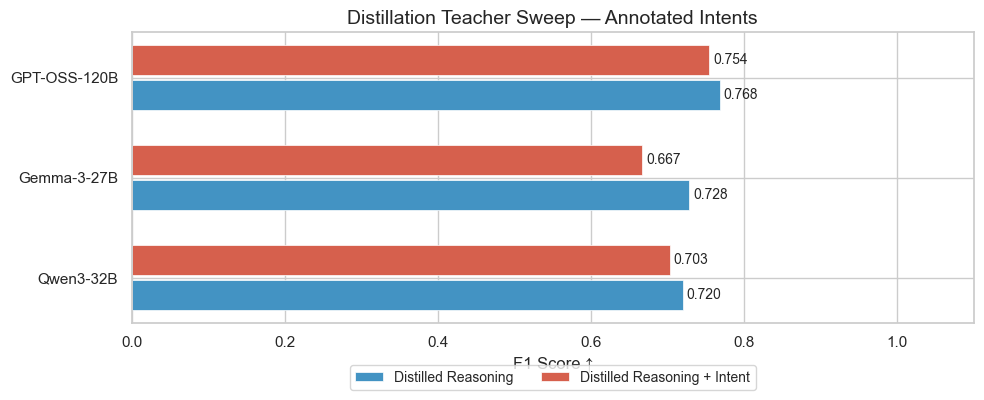

In [5]:
plot_benchmark(df, "Annotated Intents", save_name="teacher_sweep_annotated_intents")

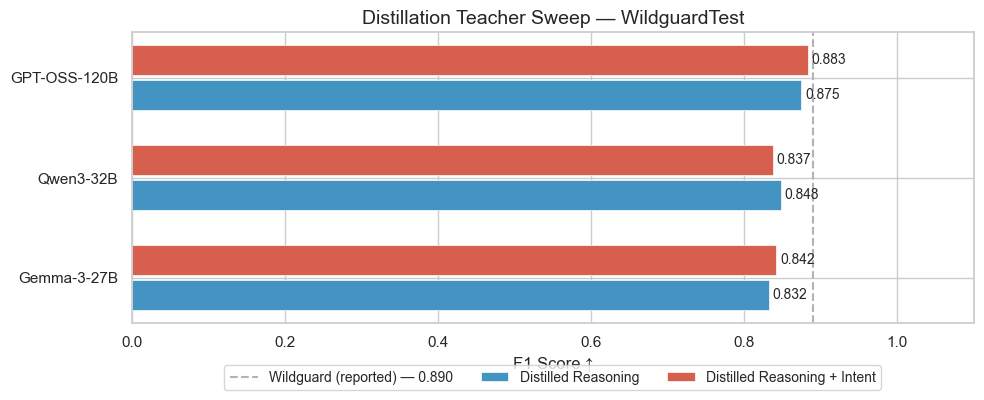

In [6]:
plot_benchmark(df, "WildguardTest", save_name="teacher_sweep_wildguardtest")

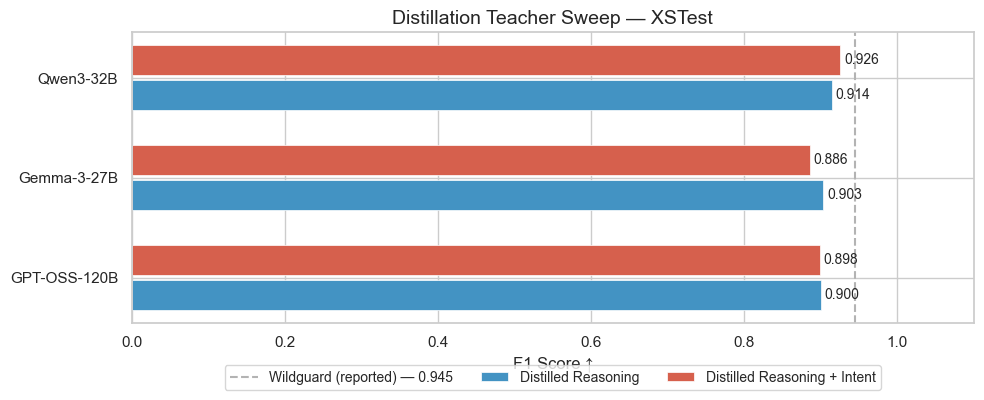

In [7]:
plot_benchmark(df, "XSTest", save_name="teacher_sweep_xstest")

## Detailed metrics table

In [8]:
cols = ["dataset", "teacher", "condition", "f1", "precision", "recall", "accuracy"]
df_display = df[cols].sort_values(["dataset", "f1"], ascending=[True, False]).reset_index(drop=True)

for col in ["f1", "precision", "recall", "accuracy"]:
    df_display[col] = df_display[col].apply(lambda x: f"{x:.4f}" if x is not None else "–")

df_display

,dataset,teacher,condition,f1,precision,recall,accuracy
0,Annotated Intents,GPT-OSS-120B,Distilled Reasoning,0.7684,0.7312,0.8095,0.7616
1,Annotated Intents,GPT-OSS-120B,Distilled Reasoning + Intent,0.7545,0.7590,0.7500,0.7616
2,Annotated Intents,Gemma-3-27B,Distilled Reasoning,0.7285,0.7857,0.6790,0.7574
3,Annotated Intents,Qwen3-32B,Distilled Reasoning,0.7195,0.7375,0.7024,0.7326
4,Annotated Intents,Qwen3-32B,Distilled Reasoning + Intent,0.7027,0.8000,0.6265,0.7427
5,Annotated Intents,Gemma-3-27B,Distilled Reasoning + Intent,0.6667,0.7286,0.6145,0.6982
6,WildguardTest,GPT-OSS-120B,Distilled Reasoning + Intent,0.8828,0.8719,0.8939,0.8945
7,WildguardTest,GPT-OSS-120B,Distilled Reasoning,0.8746,0.8489,0.9019,0.8852
8,WildguardTest,Qwen3-32B,Distilled Reasoning,0.8475,0.8287,0.8672,0.8616
9,WildguardTest,Gemma-3-27B,Distilled Reasoning + Intent,0.8421,0.8773,0.8096,0.8654
